In [1]:
import pandas as pd
import numpy as np
import os
import re
import glob
from zoneinfo import ZoneInfo
from datetime import datetime
from flaml import AutoML
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

dir_path = "D:/research assistant/EEG/Machine Learning/"
log_path = os.path.join(dir_path, "log_GBL")
processed_path = os.path.join(dir_path, "Processed GBL Files")
segment_path = os.path.join(dir_path, "segment_GBL")
eeg_file = os.path.join(dir_path, "all_subjects_power_bands_averaged_channels_GBL.xlsx")
label_dir = os.path.join(dir_path, "labelled files_GBL")

def get_file(pattern, path):
    matching_files = glob.glob(pattern)
    if not matching_files:
        raise FileNotFoundError(f"No file found for subject with pattern: {pattern}")
    file = os.path.join(path, matching_files[0])
    df = pd.read_excel(file)
    return df

In [2]:
actions = [
    "start_game",
    "start_timer",
    "start_stage",
    "game_tutorial", 
    "game_site_navigation", 
    "game_hazard_search", 
    "game_hint_viewing",
    "game_hazard_identification",
    "game_hazard_quiz_answer",
    "game_quiz_feedback_review",
    "game_risk_rating_input",
    "game_show_more_reading",
    "game_risk_rating_review",
    "game_mitigation_option_view",
    "game_mitigation_feedback_review",
    "game_summary_review",
    "irrelevant_navigation",
    "game_redo",
    "press_complete", 
    'press_snl_submit', 
    'press_mcq_next', 
    'end_guide', 
    'press_esc', 
    'answer_hazard', 
    'answer_mitigation_mcq', 
    'press_snl_done', 
    'press_mitigation_done', 
    'start_guide', 
    'press_checkpoint', 
    'answer_mcq', 
    'press_summary_next', 
    'time_checking', 
    'press_hazard',
    'press_show_more', 
    'press_redo', 
    'press_hint'
    ]
len(actions)

36

In [3]:
def process(actions):
    action_df = pd.DataFrame()
    for filename in os.listdir(processed_path):
        subject_data = pd.DataFrame()
        processed_file_path = os.path.join(processed_path, filename)
        # read processed files, we only need the time segment so any sheet will do
        processed_df = pd.read_excel(processed_file_path, sheet_name="process")
        # find the index of the subject to locate the related clean file and raw file
        number = re.findall(r'p0*(\d*)', filename)[0]
        try:
            # get the corresponding clean file
            log_pattern = os.path.join(log_path, f"log_*_p{number.zfill(3)}.xlsx")
            log_df = get_file(log_pattern, log_path)
            log_df['time'] = pd.to_datetime(log_df['time'], format="%Y-%m-%d %H:%M:%S").dt.tz_localize("Asia/Singapore").astype("int64") // 10**9
            # get the corresponding labelled file
            label_pattern = os.path.join(label_dir, f"p{number.zfill(3)}*.xlsx")
            label_df = get_file(label_pattern, label_dir)
            label_df['time'] = pd.to_datetime(label_df['time'], format="%Y-%m-%d %H:%M:%S").dt.tz_localize("Asia/Singapore").astype("int64") // 10**9
            check_time_col = []
            label_df = label_df.fillna("")
            label_df.columns = label_df.columns.str.strip()
            if "validation" in label_df.columns:
                label_df = label_df.rename(columns={"validation": "Validation"})
            for i, r in label_df.iterrows():
                if r['Validation']:
                    check_time_col.append("time_checking") if "time_checking" in r['Validation'] else check_time_col.append("")
                else:
                    check_time_col.append("")

            label_df['time_checking'] = check_time_col
            label_df = label_df[['time', 'time_checking']]
            df = pd.merge(label_df, log_df, on="time", how='left').fillna("")
        except Exception as e:
            print(number)
            print(e)
            continue
        output_path = os.path.join(segment_path, number)
        filename_col = []
        for index, row in processed_df.iterrows():
            # convert the epoch time to local time zone
            start = row['start_time'].replace(tzinfo=ZoneInfo("Asia/Singapore")).timestamp()
            end = row['end_time'].replace(tzinfo=ZoneInfo("Asia/Singapore")).timestamp()
            start_time= row['start_time'].strftime("%Y-%m-%d %H-%M-%S")
            end_time = row['end_time'].strftime("%Y-%m-%d %H-%M-%S")
            filename_col.append(f"{start_time}_{end_time}.xlsx")
            segment = df[(df['time'] >= start) & (df['time'] < end + 1)]
            action_counts = segment['type'].value_counts()
            label_segment = segment[['time', 'time_checking']].drop_duplicates(subset=['time'])
            label_counts = {}
            vc = label_segment['time_checking'].value_counts()
            for value, count in vc.items():
                if value != '':
                    label_counts[value] = count
            counts = action_counts.to_dict()
            counts.update(label_counts)
            segment_row = pd.DataFrame([counts])
            subject_data = pd.concat([subject_data, segment_row], ignore_index=True).fillna(0).astype(int)
        subject_data.columns = [
            "".join(map(str, col)) if isinstance(col, tuple) else str(col)
            for col in subject_data.columns
        ]
        subject_data = subject_data.reindex(columns=actions)
        subject_data = subject_data.fillna(0)
        subject_data['subject'] = int(number)
        subject_data['segment_file'] = filename_col
        action_df = pd.concat([action_df, subject_data], ignore_index=True)
    return action_df
    

In [4]:
action_df = process(actions)
eeg_df = pd.read_excel(eeg_file)
final_df = pd.merge(action_df, eeg_df, on=["segment_file", "subject"])
final_df = final_df[final_df["process_category"] != "OT"]
final_df.to_excel(os.path.join(dir_path, "combined_GBL.xlsx"))
cols = ["Delta", "Theta", "Alpha", "Beta", "Gamma"] + actions
scaler = StandardScaler()
final_df[cols] = scaler.fit_transform(final_df[cols])
final_df = final_df.fillna(0)

34
No file found for subject with pattern: D:/research assistant/EEG/Machine Learning/labelled files_GBL\p034*.xlsx


In [ ]:
action_df = process(actions)
eeg_df = pd.read_excel(eeg_file)
final_df = pd.merge(action_df, eeg_df, on=["segment_file", "subject"])
final_df = final_df[final_df["process_category"] != "OT"]
final_df.to_excel(os.path.join(dir_path, "combined_GBL.xlsx"))
cols = actions + ["Delta", "Theta", "Alpha", "Beta", "Gamma"]
scaler = StandardScaler()
final_df[cols] = scaler.fit_transform(final_df[cols])
final_df = final_df.fillna(0)
mapping = {'cog (high)': 'cog', 'cog': 'cog', 'meta':'meta'}
final_df["process_category"] = final_df["process_category"].replace(mapping)

34
No file found for subject with pattern: D:/research assistant/EEG/Machine Learning/labelled files_GBL\p034*.xlsx


[flaml.automl.logger: 05-05 16:24:30] {2375} INFO - task = classification
[flaml.automl.logger: 05-05 16:24:30] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 05-05 16:24:30] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 05-05 16:24:30] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 05-05 16:24:30] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 05-05 16:24:31] {3046} INFO - Estimated sufficient time budget=1085s. Estimated necessary time budget=25s.
[flaml.automl.logger: 05-05 16:24:31] {3097} INFO -  at 0.2s,	estimator lgbm's best error=2.2065e-01,	best estimator lgbm's best error=2.2065e-01
[flaml.automl.logger: 05-05 16:24:31] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 05-05 16:24:31] {3097} INFO -  at 0.3s,	estimator lgbm's best error=2.2065e-01,	best estimator lgbm's best error=2.2065e-01
[flaml.auto

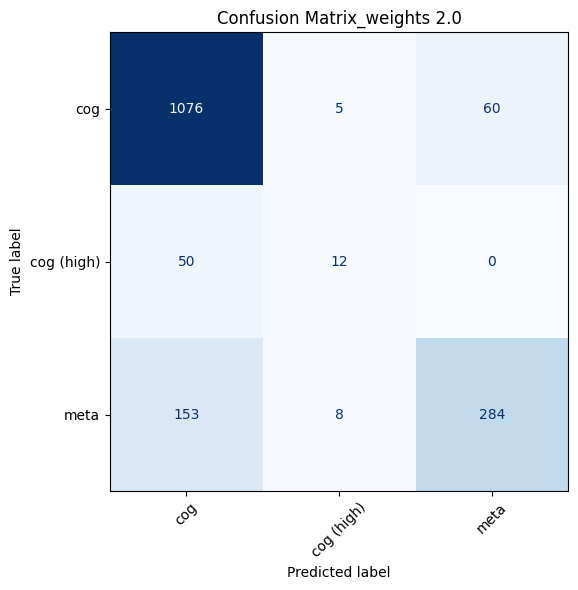

[flaml.automl.logger: 05-05 16:29:31] {2375} INFO - task = classification
[flaml.automl.logger: 05-05 16:29:31] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 05-05 16:29:31] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 05-05 16:29:31] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 05-05 16:29:31] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 05-05 16:29:31] {3046} INFO - Estimated sufficient time budget=1255s. Estimated necessary time budget=29s.
[flaml.automl.logger: 05-05 16:29:31] {3097} INFO -  at 0.2s,	estimator lgbm's best error=2.4803e-01,	best estimator lgbm's best error=2.4803e-01
[flaml.automl.logger: 05-05 16:29:31] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 05-05 16:29:31] {3097} INFO -  at 0.3s,	estimator lgbm's best error=2.4803e-01,	best estimator lgbm's best error=2.4803e-01
[flaml.auto

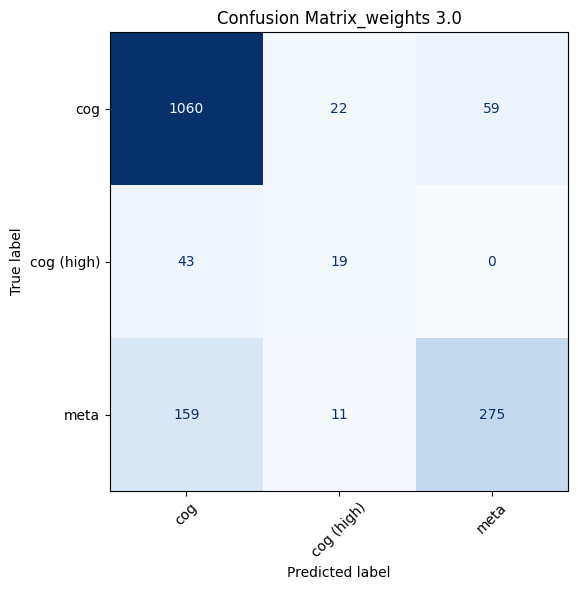

[flaml.automl.logger: 05-05 16:34:31] {2375} INFO - task = classification
[flaml.automl.logger: 05-05 16:34:31] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 05-05 16:34:31] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 05-05 16:34:31] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 05-05 16:34:31] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 05-05 16:34:31] {3046} INFO - Estimated sufficient time budget=1075s. Estimated necessary time budget=25s.
[flaml.automl.logger: 05-05 16:34:31] {3097} INFO -  at 0.2s,	estimator lgbm's best error=2.7368e-01,	best estimator lgbm's best error=2.7368e-01
[flaml.automl.logger: 05-05 16:34:31] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 05-05 16:34:31] {3097} INFO -  at 0.3s,	estimator lgbm's best error=2.7368e-01,	best estimator lgbm's best error=2.7368e-01
[flaml.auto

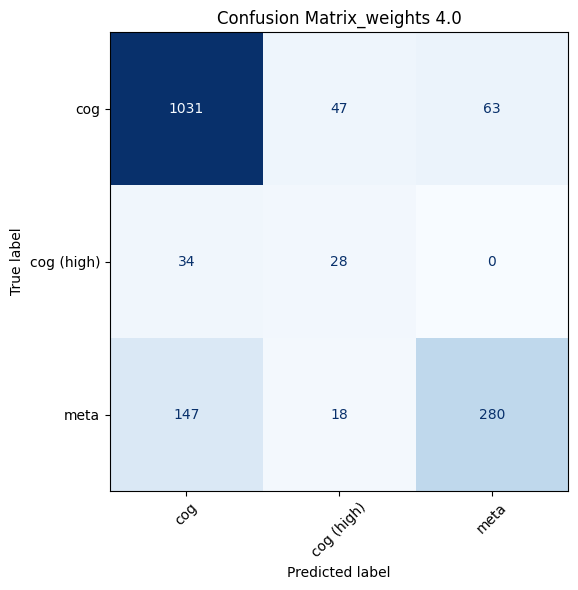

[flaml.automl.logger: 05-05 16:39:32] {2375} INFO - task = classification
[flaml.automl.logger: 05-05 16:39:32] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 05-05 16:39:32] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 05-05 16:39:32] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 05-05 16:39:32] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 05-05 16:39:32] {3046} INFO - Estimated sufficient time budget=1035s. Estimated necessary time budget=24s.
[flaml.automl.logger: 05-05 16:39:32] {3097} INFO -  at 0.2s,	estimator lgbm's best error=2.9832e-01,	best estimator lgbm's best error=2.9832e-01
[flaml.automl.logger: 05-05 16:39:32] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 05-05 16:39:32] {3097} INFO -  at 0.3s,	estimator lgbm's best error=2.9832e-01,	best estimator lgbm's best error=2.9832e-01
[flaml.auto

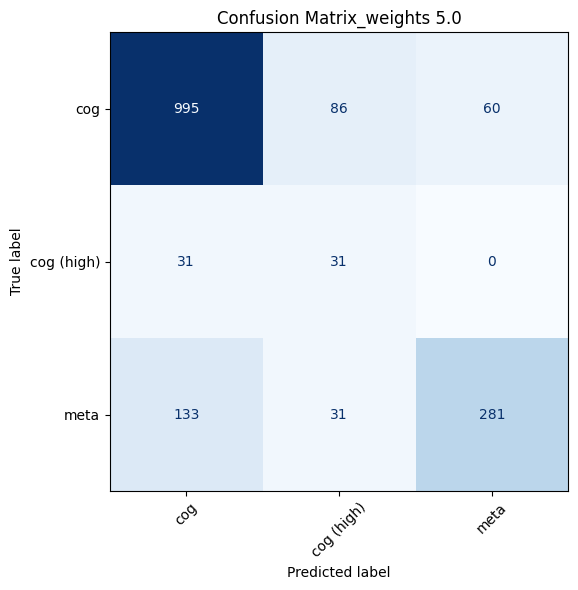

[flaml.automl.logger: 05-05 16:44:32] {2375} INFO - task = classification
[flaml.automl.logger: 05-05 16:44:32] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 05-05 16:44:32] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 05-05 16:44:32] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 05-05 16:44:32] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 05-05 16:44:32] {3046} INFO - Estimated sufficient time budget=1045s. Estimated necessary time budget=24s.
[flaml.automl.logger: 05-05 16:44:32] {3097} INFO -  at 0.2s,	estimator lgbm's best error=3.4778e-01,	best estimator lgbm's best error=3.4778e-01
[flaml.automl.logger: 05-05 16:44:32] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 05-05 16:44:32] {3097} INFO -  at 0.3s,	estimator lgbm's best error=3.4778e-01,	best estimator lgbm's best error=3.4778e-01
[flaml.auto

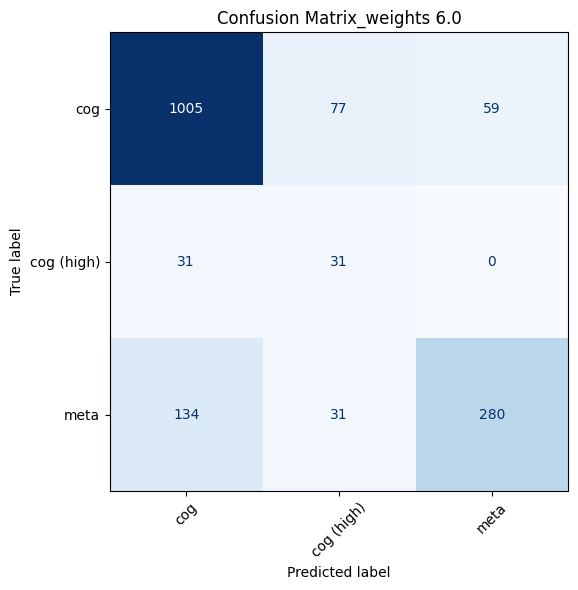

[flaml.automl.logger: 05-05 16:49:32] {2375} INFO - task = classification
[flaml.automl.logger: 05-05 16:49:32] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 05-05 16:49:32] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 05-05 16:49:32] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 05-05 16:49:32] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 05-05 16:49:33] {3046} INFO - Estimated sufficient time budget=1055s. Estimated necessary time budget=24s.
[flaml.automl.logger: 05-05 16:49:33] {3097} INFO -  at 0.2s,	estimator lgbm's best error=3.6874e-01,	best estimator lgbm's best error=3.6874e-01
[flaml.automl.logger: 05-05 16:49:33] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 05-05 16:49:33] {3097} INFO -  at 0.3s,	estimator lgbm's best error=3.6874e-01,	best estimator lgbm's best error=3.6874e-01
[flaml.auto

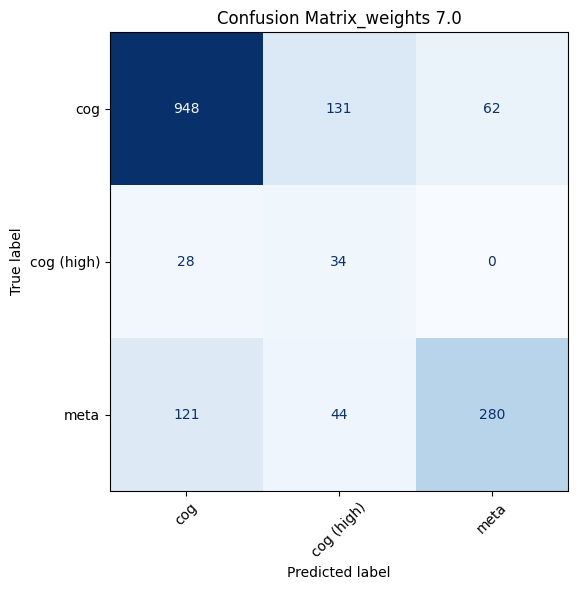

   weight  accuracy  weighted_precision  weighted_recall  weighted_f1
0     2.0  0.832524            0.823451         0.832524     0.820449
1     3.0  0.821602            0.817605         0.821602     0.814003
2     4.0  0.812500            0.820713         0.812500     0.812217
4     6.0  0.798544            0.826134         0.798544     0.806657
3     5.0  0.793083            0.824778         0.793083     0.803215
5     7.0  0.765777            0.825508         0.765777     0.788132


,weight,accuracy,weighted_precision,weighted_recall,weighted_f1,best_config
0,2.0,0.832524,0.823451,0.832524,0.820449,"{'n_estimators': 62, 'num_leaves': 10, 'min_ch..."
1,3.0,0.821602,0.817605,0.821602,0.814003,"{'n_estimators': 22, 'max_leaves': 35, 'min_ch..."
2,4.0,0.812500,0.820713,0.812500,0.812217,"{'n_estimators': 125, 'max_leaves': 4, 'min_ch..."
4,6.0,0.798544,0.826134,0.798544,0.806657,"{'n_estimators': 68, 'max_leaves': 8, 'min_chi..."
3,5.0,0.793083,0.824778,0.793083,0.803215,"{'n_estimators': 281, 'num_leaves': 4, 'min_ch..."
5,7.0,0.765777,0.825508,0.765777,0.788132,"{'n_estimators': 33, 'max_features': 0.1741828..."


In [9]:
target_col = "process_category"
# action + eeg columns + time checking
features = actions + ["Delta", "Theta",	"Alpha", "Beta", "Gamma"]
X = final_df[features]
y = final_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
weights_option = [2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
results = []
for i in weights_option:
    weights = np.where(y_train == 'cog (high)', i, 1.0)
    automl = AutoML()
    automl.fit(
        X_train=X_train,
        y_train=y_train,
        sample_weight=weights,
        task="classification",
        time_budget=300,
        metric="accuracy"
    )
    print("Best model:", automl.model)
    print("Best config:", automl.best_config)

    y_pred = automl.predict(X_test)

    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append({
        "weight": i,
        "accuracy": accuracy_score(y_test, y_pred),
        "weighted_precision": precision_w,
        "weighted_recall": recall_w,
        "weighted_f1": f1_w,
        "best_config": automl.best_config
    })

    print("Test accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    print(pd.DataFrame(cm, index=automl.classes_, columns=automl.classes_))

    cm = confusion_matrix(y_test, y_pred, labels=automl.classes_)

    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=automl.classes_)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
    ax.set_title(f"Confusion Matrix_weights {i}")
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results).sort_values("weighted_f1", ascending=False)
print(results_df[["weight", "accuracy", "weighted_precision", "weighted_recall", "weighted_f1"]])
results_df

In [20]:
X_test

,start_game,start_timer,start_stage,game_tutorial,game_site_navigation,game_hazard_search,game_hint_viewing,game_hazard_identification,game_hazard_quiz_answer,game_quiz_feedback_review,...,time_checking,press_hazard,press_show_more,press_redo,press_hint,Delta,Theta,Alpha,Beta,Gamma
627,-0.015583,-0.089869,-0.086371,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.165656,-0.327779,-0.105098,-0.022041,-0.041259,-1.024429,-0.583052,-0.328802,-0.204905,-0.143760
7144,-0.015583,-0.089869,-0.086371,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.165656,2.665843,-0.105098,-0.022041,-0.041259,0.303231,0.235617,0.095019,-0.176535,-0.186244
6492,-0.015583,-0.089869,-0.086371,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.165656,2.665843,-0.105098,-0.022041,-0.041259,-0.257691,-0.122580,-0.290468,-0.277422,-0.334929
3177,-0.015583,-0.089869,-0.086371,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.165656,-0.327779,-0.105098,-0.022041,-0.041259,-0.816177,-0.420787,-0.249165,-0.257937,-0.285434
1548,-0.015583,-0.089869,-0.086371,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.165656,-0.327779,-0.105098,-0.022041,-0.041259,-0.468824,-0.350222,0.050650,0.126236,0.013682
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8054,-0.015583,-0.089869,-0.086371,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.165656,-0.327779,-0.105098,-0.022041,-0.041259,3.799701,2.062389,0.605643,-0.026687,-0.052914
124,-0.015583,-0.089869,-0.086371,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.165656,-0.327779,-0.105098,-0.022041,-0.041259,-0.821047,-0.429302,-0.092530,-0.213732,-0.246987
4180,-0.015583,-0.089869,-0.086371,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.165656,-0.327779,-0.105098,-0.022041,-0.041259,-0.917666,-0.562239,-0.321195,-0.190309,-0.159577
612,-0.015583,-0.089869,-0.086371,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.165656,-0.327779,-0.105098,-0.022041,-0.041259,-0.711261,-0.390020,-0.338470,-0.217924,-0.237262


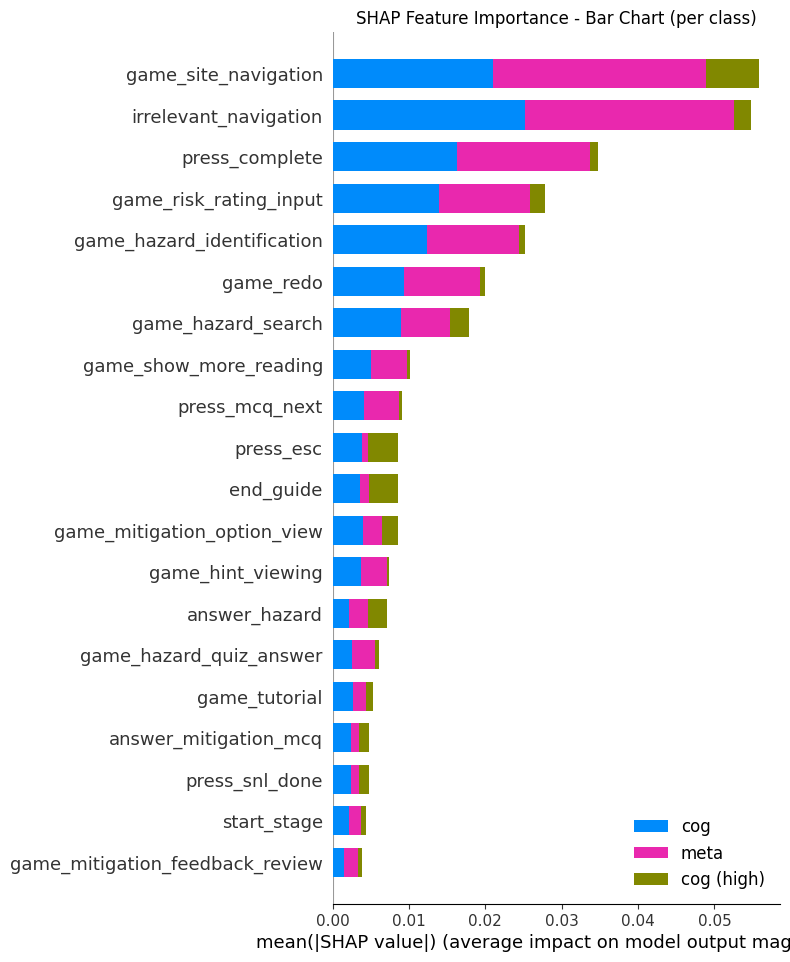

In [19]:
import shap

labels = ['cog', 'cog (high)', 'meta']
best_model = automl.model.estimator
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, class_names=labels)
plt.title("SHAP Feature Importance - Bar Chart (per class)")
plt.show()

[flaml.automl.logger: 04-22 09:48:05] {2375} INFO - task = classification
[flaml.automl.logger: 04-22 09:48:05] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 04-22 09:48:05] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 04-22 09:48:05] {2606} INFO - List of ML learners in AutoML Run: ['lgbm']
[flaml.automl.logger: 04-22 09:48:05] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 04-22 09:48:05] {3046} INFO - Estimated sufficient time budget=1155s. Estimated necessary time budget=1s.
[flaml.automl.logger: 04-22 09:48:05] {3097} INFO -  at 0.2s,	estimator lgbm's best error=1.9120e-01,	best estimator lgbm's best error=1.9120e-01
[flaml.automl.logger: 04-22 09:48:05] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 04-22 09:48:05] {3097} INFO -  at 0.3s,	estimator lgbm's best error=1.9120e-01,	best estimator lgbm's best error=1.9120e-01
[flaml.automl.logger: 04-22 09:48:05] {2911} INFO - iteration 2, current lea

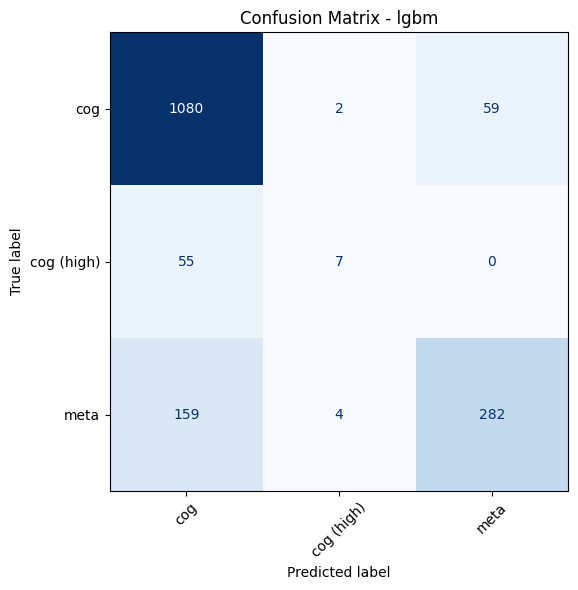

[flaml.automl.logger: 04-22 09:53:05] {2375} INFO - task = classification
[flaml.automl.logger: 04-22 09:53:05] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 04-22 09:53:05] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 04-22 09:53:05] {2606} INFO - List of ML learners in AutoML Run: ['xgboost']
[flaml.automl.logger: 04-22 09:53:05] {2911} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 04-22 09:53:06] {3046} INFO - Estimated sufficient time budget=5967s. Estimated necessary time budget=6s.
[flaml.automl.logger: 04-22 09:53:06] {3097} INFO -  at 0.7s,	estimator xgboost's best error=1.8649e-01,	best estimator xgboost's best error=1.8649e-01
[flaml.automl.logger: 04-22 09:53:06] {2911} INFO - iteration 1, current learner xgboost
[flaml.automl.logger: 04-22 09:53:06] {3097} INFO -  at 0.8s,	estimator xgboost's best error=1.8649e-01,	best estimator xgboost's best error=1.8649e-01
[flaml.automl.logger: 04-22 09:53:06] {2911} INFO - ite

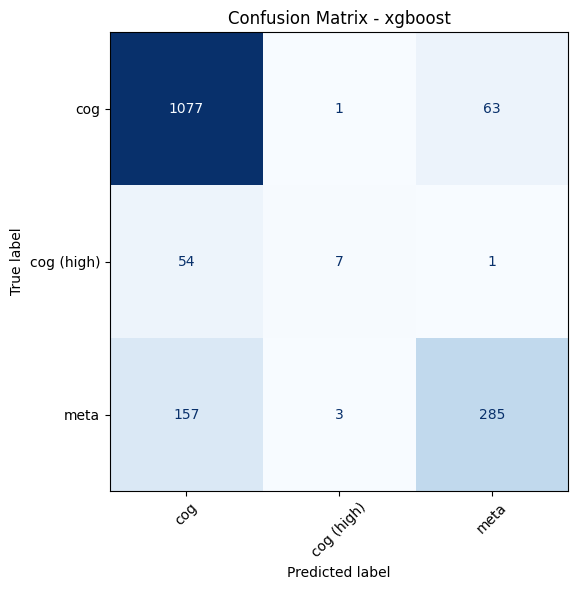

[flaml.automl.logger: 04-22 09:58:05] {2375} INFO - task = classification
[flaml.automl.logger: 04-22 09:58:05] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 04-22 09:58:05] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 04-22 09:58:05] {2606} INFO - List of ML learners in AutoML Run: ['xgb_limitdepth']
[flaml.automl.logger: 04-22 09:58:05] {2911} INFO - iteration 0, current learner xgb_limitdepth
[flaml.automl.logger: 04-22 09:58:06] {3046} INFO - Estimated sufficient time budget=2465s. Estimated necessary time budget=2s.
[flaml.automl.logger: 04-22 09:58:06] {3097} INFO -  at 0.3s,	estimator xgb_limitdepth's best error=1.6313e-01,	best estimator xgb_limitdepth's best error=1.6313e-01
[flaml.automl.logger: 04-22 09:58:06] {2911} INFO - iteration 1, current learner xgb_limitdepth
[flaml.automl.logger: 04-22 09:58:06] {3097} INFO -  at 0.5s,	estimator xgb_limitdepth's best error=1.6313e-01,	best estimator xgb_limitdepth's best error=1.6313e-01
[flaml

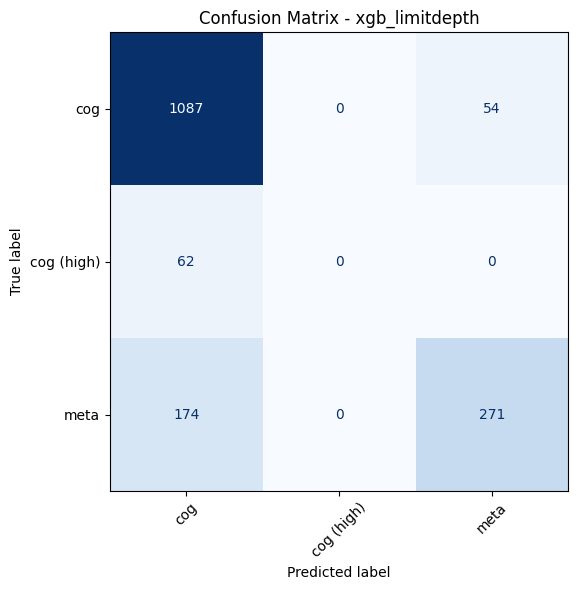

[flaml.automl.logger: 04-22 10:03:05] {2375} INFO - task = classification
[flaml.automl.logger: 04-22 10:03:05] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 04-22 10:03:05] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 04-22 10:03:05] {2606} INFO - List of ML learners in AutoML Run: ['rf']
[flaml.automl.logger: 04-22 10:03:05] {2911} INFO - iteration 0, current learner rf
[flaml.automl.logger: 04-22 10:03:05] {3046} INFO - Estimated sufficient time budget=3085s. Estimated necessary time budget=3s.
[flaml.automl.logger: 04-22 10:03:05] {3097} INFO -  at 0.4s,	estimator rf's best error=2.7026e-01,	best estimator rf's best error=2.7026e-01
[flaml.automl.logger: 04-22 10:03:05] {2911} INFO - iteration 1, current learner rf
[flaml.automl.logger: 04-22 10:03:06] {3097} INFO -  at 0.7s,	estimator rf's best error=1.8346e-01,	best estimator rf's best error=1.8346e-01
[flaml.automl.logger: 04-22 10:03:06] {2911} INFO - iteration 2, current learner rf
[flaml

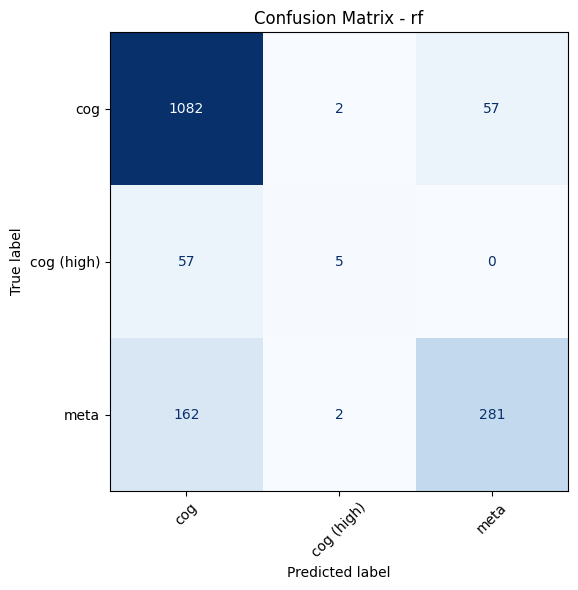

[flaml.automl.logger: 04-22 10:08:05] {2375} INFO - task = classification
[flaml.automl.logger: 04-22 10:08:05] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 04-22 10:08:05] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 04-22 10:08:05] {2606} INFO - List of ML learners in AutoML Run: ['extra_tree']
[flaml.automl.logger: 04-22 10:08:05] {2911} INFO - iteration 0, current learner extra_tree
[flaml.automl.logger: 04-22 10:08:05] {3046} INFO - Estimated sufficient time budget=3534s. Estimated necessary time budget=4s.
[flaml.automl.logger: 04-22 10:08:05] {3097} INFO -  at 0.4s,	estimator extra_tree's best error=3.0106e-01,	best estimator extra_tree's best error=3.0106e-01
[flaml.automl.logger: 04-22 10:08:05] {2911} INFO - iteration 1, current learner extra_tree
[flaml.automl.logger: 04-22 10:08:06] {3097} INFO -  at 0.7s,	estimator extra_tree's best error=2.1411e-01,	best estimator extra_tree's best error=2.1411e-01
[flaml.automl.logger: 04-22 10:08:

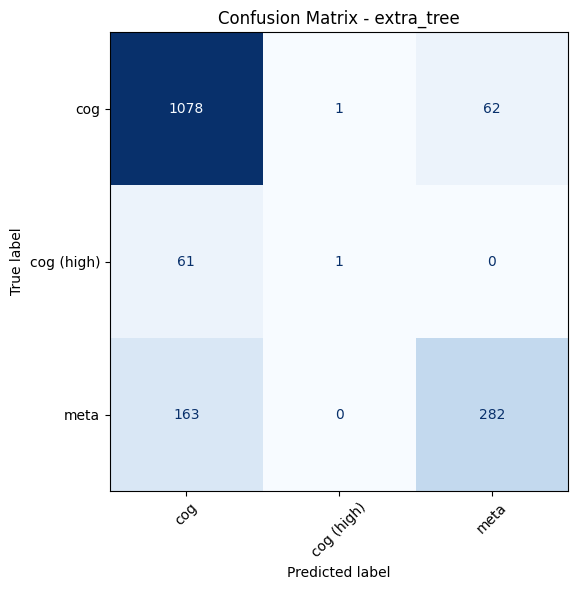

[flaml.automl.logger: 04-22 10:13:05] {2375} INFO - task = classification
[flaml.automl.logger: 04-22 10:13:05] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 04-22 10:13:05] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 04-22 10:13:05] {2606} INFO - List of ML learners in AutoML Run: ['lrl1']
[flaml.automl.logger: 04-22 10:13:05] {2911} INFO - iteration 0, current learner lrl1
[flaml.automl.logger: 04-22 10:13:07] {3046} INFO - Estimated sufficient time budget=16914s. Estimated necessary time budget=17s.
[flaml.automl.logger: 04-22 10:13:07] {3097} INFO -  at 1.7s,	estimator lrl1's best error=1.6115e-01,	best estimator lrl1's best error=1.6115e-01
[flaml.automl.logger: 04-22 10:13:07] {2911} INFO - iteration 1, current learner lrl1
[flaml.automl.logger: 04-22 10:13:08] {3097} INFO -  at 3.4s,	estimator lrl1's best error=1.6055e-01,	best estimator lrl1's best error=1.6055e-01
[flaml.automl.logger: 04-22 10:13:08] {2911} INFO - iteration 2, current l

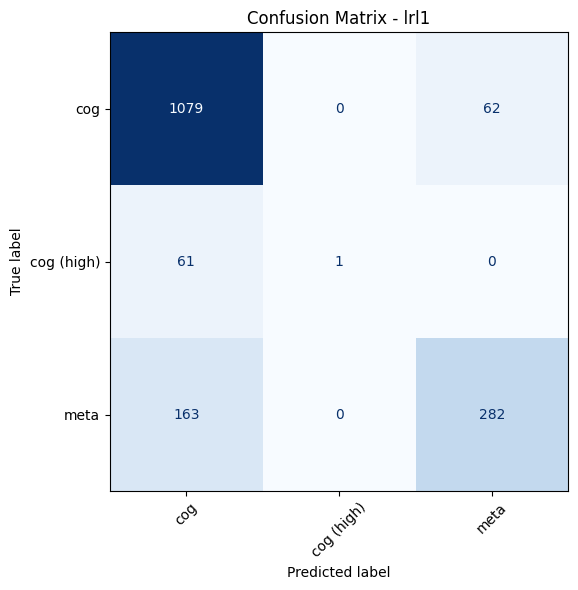

[flaml.automl.logger: 04-22 10:18:05] {2375} INFO - task = classification
[flaml.automl.logger: 04-22 10:18:05] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 04-22 10:18:05] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 04-22 10:18:05] {2606} INFO - List of ML learners in AutoML Run: ['sgd']
[flaml.automl.logger: 04-22 10:18:05] {2911} INFO - iteration 0, current learner sgd
[flaml.automl.logger: 04-22 10:18:06] {3046} INFO - Estimated sufficient time budget=6953s. Estimated necessary time budget=7s.
[flaml.automl.logger: 04-22 10:18:06] {3097} INFO -  at 0.8s,	estimator sgd's best error=1.7390e-01,	best estimator sgd's best error=1.7390e-01
[flaml.automl.logger: 04-22 10:18:06] {2911} INFO - iteration 1, current learner sgd
[flaml.automl.logger: 04-22 10:18:06] {3097} INFO -  at 1.4s,	estimator sgd's best error=1.6297e-01,	best estimator sgd's best error=1.6297e-01
[flaml.automl.logger: 04-22 10:18:06] {2911} INFO - iteration 2, current learner sg

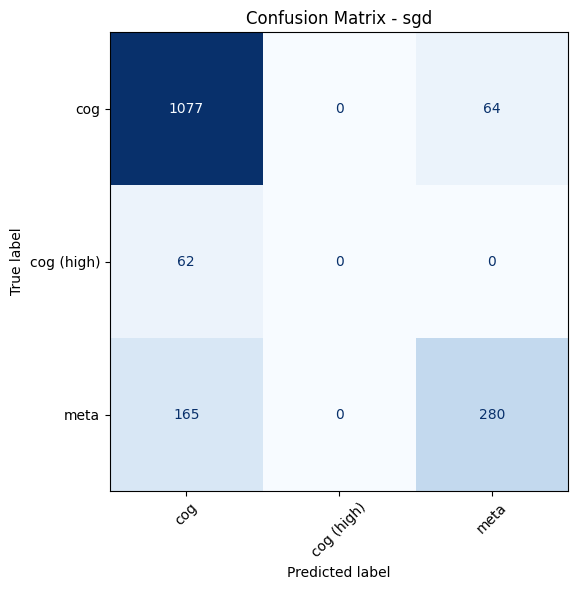

            model  accuracy  weighted_precision  weighted_recall  weighted_f1
1         xgboost  0.830704            0.823381         0.830704     0.815030
0            lgbm  0.830704            0.821416         0.830704     0.814943
3              rf  0.830097            0.821197         0.830097     0.812645
5            lrl1  0.826456            0.832310         0.826456     0.805550
4      extra_tree  0.825850            0.813407         0.825850     0.805214
6             sgd  0.823422            0.791617         0.823422     0.801604
2  xgb_limitdepth  0.824029            0.794009         0.824029     0.800937


,model,accuracy,weighted_precision,weighted_recall,weighted_f1,best_config
1,xgboost,0.830704,0.823381,0.830704,0.815030,"{'n_estimators': 14, 'max_leaves': 10, 'min_ch..."
0,lgbm,0.830704,0.821416,0.830704,0.814943,"{'n_estimators': 13, 'num_leaves': 11, 'min_ch..."
3,rf,0.830097,0.821197,0.830097,0.812645,"{'n_estimators': 53, 'max_features': 0.3212664..."
5,lrl1,0.826456,0.832310,0.826456,0.805550,{'C': 0.24999999999999997}
4,extra_tree,0.825850,0.813407,0.825850,0.805214,"{'n_estimators': 26, 'max_features': 0.3774275..."
6,sgd,0.823422,0.791617,0.823422,0.801604,"{'penalty': 'None', 'alpha': 0.1, 'l1_ratio': ..."
2,xgb_limitdepth,0.824029,0.794009,0.824029,0.800937,"{'n_estimators': 15, 'max_depth': 8, 'min_chil..."


In [6]:
estimators = [
    "lgbm",
    "xgboost",
    "xgb_limitdepth",
    "rf",
    "extra_tree",
    "lrl1",
    "sgd",
]

results = []
target_col = "process_category"
# action + eeg columns + time checking
features = actions + ["Delta", "Theta",	"Alpha", "Beta", "Gamma"]
X = final_df[features]
y = final_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
for est in estimators:
    automl = AutoML()
    automl.fit(
        X_train=X_train,
        y_train=y_train,
        task="classification",
        metric="accuracy",
        time_budget=300,
        estimator_list=[est],
        eval_method="cv",
        n_splits=5
    )

    y_pred = automl.predict(X_test)

    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append({
        "model": est,
        "accuracy": accuracy_score(y_test, y_pred),
        "weighted_precision": precision_w,
        "weighted_recall": recall_w,
        "weighted_f1": f1_w,
        "best_config": automl.best_config
    })

    cm = confusion_matrix(y_test, y_pred, labels=automl.classes_)

    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=automl.classes_)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
    ax.set_title(f"Confusion Matrix - {est}")
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results).sort_values("weighted_f1", ascending=False)
print(results_df[["model", "accuracy", "weighted_precision", "weighted_recall", "weighted_f1"]])
results_df


In [7]:
results_df.to_excel("gbl_ml.xlsx")